In [6]:
from pathlib import Path
import pygimli as pg  
from pygimli.physics import ert
import matplotlib.pyplot as plt
from datetime import datetime
import os
import numpy as np

from Hilfsfunktionen import T_corr_nach_Inversion
from Hilfsfunktionen import plotting_function

# Read data
file = "two_timesteps_240710_240808.ohm"
two_timesteps = True
base_dir = Path("filtered_data")
data = []
for unterordner in base_dir.iterdir():
    if unterordner.is_dir():
        datei_pfad = unterordner / "two_timesteps_240710_240808.ohm" 
        if datei_pfad.exists():
            daten_objekt = pg.load(str(datei_pfad))
            data.append([unterordner.name, daten_objekt])
            print(f"Load data: {datei_pfad}")

# Create method manager
manager = []
for ts in data:
    manager.append(ert.ERTManager(ts[1], verbose=True))

# Create mesh
mesh = manager[0].createMesh(quality = 34, paraMaxCellSize=0.5, paraDepth=15)

# Inversion without temperature correction
results_tl = []
manager_list_tl = []
chi2_oT = []
chi2_wT = []
chi2 = []
lam=112
for mgr,mgr_number in zip(manager, range(len(manager))):
    print(mgr_number)
    if mgr_number == 1:
        dat = mgr.data
        dataD = dat.copy()
        dataD["rhoa"] = dat["rhoa"] * manager[mgr_number-1].inv.response / manager[mgr_number-1].inv.dataVals
        dataD["err"] = np.sqrt((manager[mgr_number-1].data['err'])**2+(manager[mgr_number].data['err'])**2)
        manager_list_tl.append(ert.Manager(dataD))
        results_tl.append(manager_list_tl[mgr_number].invert(manager_list_tl[mgr_number].data, quality=34,paraMaxCellSize=0.5,
                    paraDepth=15,lam=lam, dPhi= 0.1, startModel=results_tl[0], isReference = True, verbose = True,stopAtChi1=False))
        chi2.append(round(manager_list_tl[mgr_number].inv.chi2(),2))
    if mgr_number == 0:
        manager_list_tl.append(mgr)
        results_tl.append(mgr.invert(mgr.data, quality=34,paraMaxCellSize=0.5, 
                                     dPhi= 0.1, paraDepth=15,lam=12, verbose= True,stopAtChi1=False)) 
        chi2.append(round(mgr.inv.chi2(),2))
        chi2_oT.append(chi2)

# Temperature correction
ort_2 = 'Georg-Westermann-Park'
results_tl_corr = [] 
temp_spread = []
timestep = 0
mesh2 = manager[0].mesh.createSubMesh(manager[0].mesh.cells(manager[0].mesh.cellMarkers() == 2))
for count, m in enumerate(results_tl):
    if two_timesteps:
        add = 10
    else:
        add = 0
    timestep = count+add
    dateien = os.listdir(r".\Temperature_data/" + ort_2 )
    for datei in dateien: 
        if (datei).startswith('T_Profil%s_array' % (str(timestep))):
            print(datei)
            Temp_tiefe_vektor = np.load(r'.\Temperature_data/%s/' % (ort_2) + datei, allow_pickle=True)
    res_new,Tem_new = T_corr_nach_Inversion(m, mesh2, Temp_tiefe_vektor)
    results_tl_corr.append(res_new) 
    temp_spread.append(Tem_new)

for resu, resu_corr, man, wen in zip(results_tl,results_tl_corr,manager_list_tl, data):
    response = man.inv.fop.response(resu)
    response_t_corr = man.inv.fop.response(resu_corr)
    difference = response_t_corr - response
    wen[1]['rhoa'] = wen[1]['rhoa'] + difference  
    
    
# Inversion with temperature correction
results_tl_Tcorr = []
manager_list_tl = []
chi2 = []
for mgr,mgr_number in zip(manager, range(len(manager))):
    print(mgr_number)
    if mgr_number == 1:
        dat = mgr.data
        dataD = dat.copy()
        dataD["rhoa"] = dat["rhoa"] * manager[mgr_number-1].inv.response / manager[mgr_number-1].inv.dataVals
        dataD["err"] = np.sqrt((manager[mgr_number-1].data['err'])**2+(manager[mgr_number].data['err'])**2)
        manager_list_tl.append(ert.Manager(dataD))
        results_tl_Tcorr.append(manager_list_tl[mgr_number].invert(manager_list_tl[mgr_number].data, quality=34,paraMaxCellSize=0.5,
                    paraDepth=15,lam=lam, dPhi= 0.1, startModel=results_tl_Tcorr[0], isReference = True, verbose = True,stopAtChi1=False))
        chi2.append(round(manager_list_tl[mgr_number].inv.chi2(),2))
    if mgr_number == 0:
        manager_list_tl.append(mgr)
        results_tl_Tcorr.append(mgr.invert(mgr.data, quality=34,paraMaxCellSize=0.5, 
                                     dPhi= 0.1, paraDepth=15,lam=12, verbose= True,stopAtChi1=False)) 
        chi2.append(round(mgr.inv.chi2(),2))
        chi2_wT.append(chi2)


Load data: filtered_data\240710\two_timesteps_240710_240808.ohm
Load data: filtered_data\240808\two_timesteps_240710_240808.ohm


31/08/25 - 15:39:30 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 15:39:30 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 15:39:31 - pyGIMLi - INFO - Creating forward mesh from region infos.
31/08/25 - 15:39:31 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.


0


31/08/25 - 15:39:32 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
31/08/25 - 15:39:32 - pyGIMLi - INFO - Use median(data values)=2117.76
31/08/25 - 15:39:32 - pyGIMLi - INFO - Created startmodel from forward operator: 3104, min/max=2117.760000/2117.760000
31/08/25 - 15:39:32 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001BEE6025B70>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x000001BEE6025440>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x000001BEE499B380>
min/max (data): 77.42/6811
min/max (error): 4.3%/4.31%
min/max (start model): 2118/2118
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  500.83
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   10.62 (dPhi = 96.96%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    8.42 (dPhi = 20.02%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    6.81 (dPhi = 18.08%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    5.51 (dPhi = 17.57%) lam: 12.0
----------

...

0
fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001BEE6025B70>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x000001BEE6025440>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x000001BEE499B380>
min/max (data): 48.92/5518
min/max (error): 4.3%/4.31%
min/max (start model): 1591/1591
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  556.18
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   12.25 (dPhi = 96.89%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    9.78 (dPhi = 19.58%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    7.83 (dPhi = 19.06%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    6.41 (dPhi = 16.82%) lam: 12.0
--------

31/08/25 - 15:50:10 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 15:50:10 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 15:50:10 - pyGIMLi - INFO - Found 2 regions.
31/08/25 - 15:50:10 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
31/08/25 - 15:50:10 - pyGIMLi - INFO - Creating forward mesh from region infos.
31/08/25 - 15:50:10 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.


chi² =    1.37 (dPhi = 0.04%) lam: 12.0
################################################################################
#                Abort criterion reached: dPhi = 0.04 (< 0.1%)                 #
################################################################################
1


31/08/25 - 15:50:11 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
31/08/25 - 15:50:11 - pyGIMLi - INFO - Starting inversion.
31/08/25 - 15:50:11 - pyGIMLi - INFO - Setting starting model as reference!


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001BEE6030770>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x000001BEE6030810>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x000001BEE6031E90>
min/max (data): 50.35/4114
min/max (error): 5.32%/5.34%
min/max (start model): 10.13/6995
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =   11.66
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    1.09 (dPhi = 85.96%) lam: 112.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    1.05 (dPhi = 2.47%) lam: 112.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.05 (dPhi = 0.00%) lam: 112.0
################################################################################
#                 Abort criterion reached: dPhi = 0.0 (< 0.1%) 

In [5]:
results_tl

[3104 [3349.6768135037137,...,27.480184494665814],
 3104 [1945.6351131024248,...,27.750462667358494]]

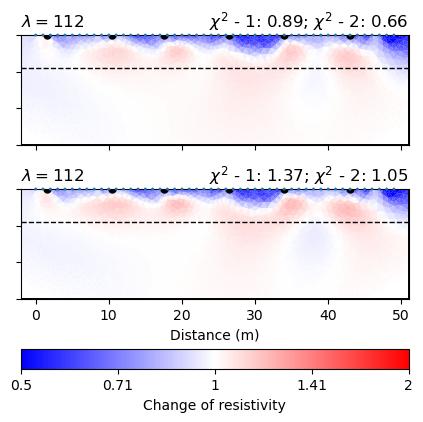

In [13]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5,6))
axs = axs.flatten()
plt.subplots_adjust(hspace=-0.5)
for nr, chi2, m, name in zip([0,1],[chi2_oT, chi2_wT], [results_tl, results_tl_Tcorr], ['withoutTcorr', 'withTcorr']):
    ratio = m[1] / m[0]
    bild2 = manager[0].showResult(model= ratio,coverage = manager[0].coverage(),
            cMin=1/2, cMax=2, cMap= 'bwr', ax= axs[nr], label = 'Change of resistivity', logScale= True)
    if nr < 1:
        cb = bild2[-1]
        cb.remove() 
        axs[nr].xaxis.set_ticklabels([])  # Unterdrückt die x-Achse Labels
    if nr == 1:
        axs[nr].set_xlabel('Distance (m)')
        
    axs[nr].yaxis.set_ticklabels([])  # Unterdrückt die y-Achse Labels
    axs[nr].set_title('$\chi^2$ - 1: '+ str(chi2[0][0]) + '; $\chi^2$ - 2: ' + str(chi2[0][1]), loc = 'right')
    axs[nr].set_title('$\lambda = $'+ str(112), loc = 'left')
    # Prinzenpark
    axs[nr].plot(1.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(10.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(17.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(26.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(34,0, '.', markersize = '10 ', color = 'black')
    axs[nr].plot(43,0, '.', markersize = '10 ', color = 'black')
    axs[nr].set_ylim(-15, 0)
    axs[nr].axhline(y=-4.5, color='k', linewidth = 1,linestyle='--')

fig.savefig('./Fig8/Diff_inversion_new.png', bbox_inches = 'tight', dpi=300)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\johan\\Nextcloud\\Promotion\\Paper1\\Paper_Repository\\Unsealed park site\\Fig11\\Diff_inversion_new2.png'

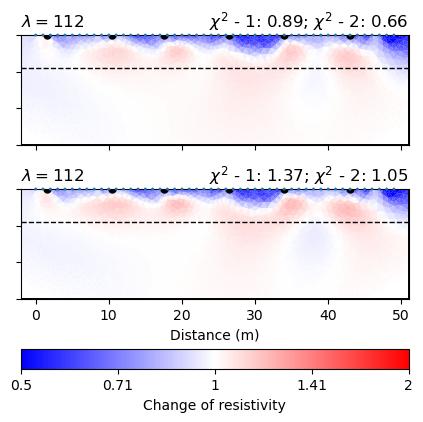

In [11]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5,6))
axs = axs.flatten()
plt.subplots_adjust(hspace=-0.5)
for nr, chi2, m, name in zip([0,1],[chi2_oT, chi2_wT], [results_tl, results_tl_Tcorr], ['withoutTcorr', 'withTcorr']):
    ratio = m[1] / m[0]
    bild2 = manager[0].showResult(model= ratio,coverage = manager[0].coverage(),
            cMin=1/2, cMax=2, cMap= 'bwr', ax= axs[nr], label = 'Change of resistivity', logScale= True)
    if nr < 1:
        cb = bild2[-1]
        cb.remove() 
        axs[nr].xaxis.set_ticklabels([])  # Unterdrückt die x-Achse Labels
    if nr == 1:
        axs[nr].set_xlabel('Distance (m)')
        
    axs[nr].yaxis.set_ticklabels([])  # Unterdrückt die y-Achse Labels
    axs[nr].set_title('$\chi^2$ - 1: '+ str(chi2[0][0]) + '; $\chi^2$ - 2: ' + str(chi2[0][1]), loc = 'right')
    axs[nr].set_title('$\lambda = $'+ str(lam), loc = 'left')
    # Prinzenpark
    axs[nr].plot(1.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(10.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(17.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(26.5,0, '.', markersize = '10', color = 'black')
    axs[nr].plot(34,0, '.', markersize = '10 ', color = 'black')
    axs[nr].plot(43,0, '.', markersize = '10 ', color = 'black')
    axs[nr].set_ylim(-15, 0)
    axs[nr].axhline(y=-4.5, color='k', linewidth = 1,linestyle='--')

fig.savefig('./Fig11/Diff_inversion_new2.png', bbox_inches = 'tight', dpi=300)